<a href="https://colab.research.google.com/github/yadavrishikesh/MA-563-Statistical-Computation-and-Simulation-/blob/main/code/module1/Practice_Lab2_BoxMuller_RatioOfUniforms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MA 563 — Statistical Computation and Simulation
## Lab 2: Box–Muller and the Ratio-of-Uniforms Method

Instructor: Dr. Rishikesh Yadav  |  TA: Vedant Vibhor

---


| Part | Topic | Slides |
|:--|:--|:--|
| 1 | Box–Muller: polar derivation, algorithm, and the trig-free polar variant | 25–27 |
| 2 | Ratio-of-uniforms: Kinderman–Monahan, bounding rectangles, worked examples | 28–31 |
| 3 | Head-to-head comparison: accuracy, tails, uniforms consumed, runtime, robustness | — |


In [ ]:
# ------------------------------------------------------------------
# Setup: run this cell first.
# ------------------------------------------------------------------
import math
import timeit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (10, 3.6), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

BLUE, ORANGE, GREEN, RED = "#003366", "#ED7D31", "#2E7D32", "#C62828"

rng = np.random.default_rng(seed=2026)


def lcg(n, m, a, c, seed, uniform=True):
    """The toy LCG from Lab 1 -- needed again in Part 3."""
    x, out = seed, []
    while len(out) < n:
        x = (a * x + c) % m
        out.append(x)
    arr = np.array(out, dtype=np.int64)
    return arr / m if uniform else arr


def check_normal(z, name, mu=0.0, sigma=1.0, bins=70):
    """Histogram vs pdf, Q-Q plot, and a KS test against N(mu, sigma^2)."""
    dist = stats.norm(mu, sigma)
    lo, hi = mu - 4.2 * sigma, mu + 4.2 * sigma
    grid = np.linspace(lo, hi, 400)

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
    ax[0].hist(z, bins=bins, range=(lo, hi), density=True, color=BLUE,
               edgecolor="white", alpha=0.85, label="generated")
    ax[0].plot(grid, dist.pdf(grid), color=ORANGE, lw=2.2, label="true pdf")
    ax[0].set_title(f"{name}: density check"); ax[0].set_xlabel("z")
    ax[0].legend(fontsize=8)

    p = (np.arange(1, 201) - 0.5) / 200
    ax[1].plot(dist.ppf(p), np.quantile(z, p), ".", ms=4, color=BLUE)
    lim = [dist.ppf(0.0005), dist.ppf(0.9995)]
    ax[1].plot(lim, lim, "--", color=ORANGE, lw=1.5)
    ax[1].set_xlim(lim); ax[1].set_ylim(lim)
    ax[1].set_title(f"{name}: Q-Q plot")
    ax[1].set_xlabel("theoretical quantile"); ax[1].set_ylabel("sample quantile")
    plt.tight_layout(); plt.show()

print("setup complete")

setup complete


---
# Part 1 — The Box–Muller Transformation

### 1.1 The idea

Take **two** independent standard normals at once. Their joint density,

$$f(z_1,z_2) = \frac{1}{2\pi}\,e^{-(z_1^2+z_2^2)/2},$$

depends on $(z_1,z_2)$ only through $z_1^2+z_2^2$ — it is **rotationally symmetric**. That
is a very strong hint to switch to polar coordinates $z_1 = r\cos\theta$,
$z_2 = r\sin\theta$. The area element is $dz_1\,dz_2 = r\,dr\,d\theta$, so

$$f(z_1,z_2)\,dz_1\,dz_2 = \underbrace{\frac{1}{2\pi}\,d\theta}_{\Theta \sim U(0,2\pi)}
\times \underbrace{r\,e^{-r^2/2}\,dr}_{\text{Rayleigh density}}.$$

The factorisation says $R$ and $\Theta$ are **independent**. Now substitute $S = R^2$
(so $dS = 2r\,dr$):

$$f_S(s) = \tfrac12 e^{-s/2}, \qquad s \ge 0,$$

which is $\mathrm{Exponential}(1/2)$, i.e. $\chi^2_2$.

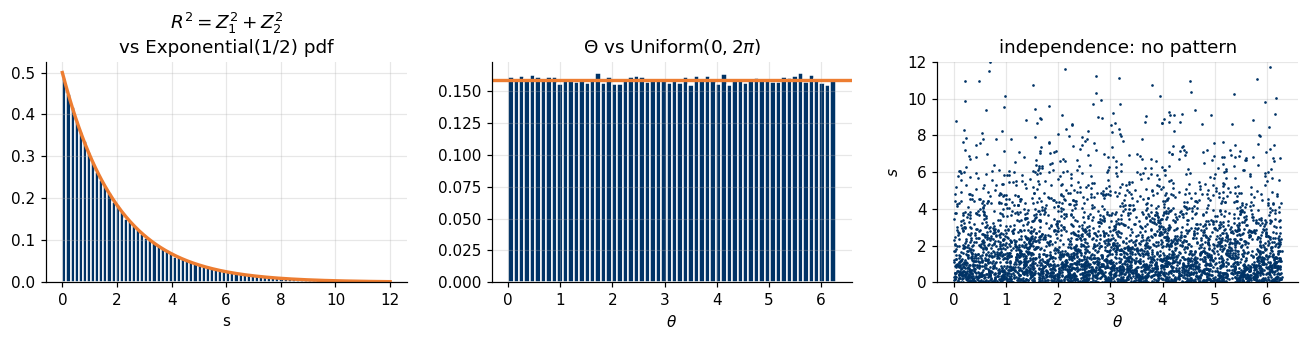

In [ ]:
# ------------------------------------------------------------------
# 1.1  Check the polar claims BEFORE using them.
#      Take genuine normals, convert to polar, and test the two claims.
# ------------------------------------------------------------------
n = 200000
z1, z2 = rng.standard_normal(n), rng.standard_normal(n)

S = z1**2 + z2**2                       # claim: Exponential(rate 1/2), i.e. chi^2_2
Theta = np.arctan2(z2, z1) % (2 * np.pi)   # claim: Uniform(0, 2*pi), independent of S

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

s_grid = np.linspace(0, 12, 300)
ax[0].hist(S, bins=80, range=(0, 12), density=True, color=BLUE, edgecolor="white")
ax[0].plot(s_grid, stats.expon(scale=2).pdf(s_grid), color=ORANGE, lw=2.2)
ax[0].set_title("$R^2 = Z_1^2+Z_2^2$\nvs Exponential(1/2) pdf"); ax[0].set_xlabel("s")

ax[1].hist(Theta, bins=60, range=(0, 2 * np.pi), density=True, color=BLUE,
           edgecolor="white")
ax[1].axhline(1 / (2 * np.pi), color=ORANGE, lw=2.2)
ax[1].set_title(r"$\Theta$ vs Uniform$(0,2\pi)$"); ax[1].set_xlabel(r"$\theta$")

ax[2].plot(Theta[:4000], S[:4000], ".", ms=1.5, color=BLUE)
ax[2].set_title("independence: no pattern"); ax[2].set_xlabel(r"$\theta$")
ax[2].set_ylabel("$s$"); ax[2].set_ylim(0, 12)

plt.tight_layout(); plt.show()

### 1.2 Running the argument backwards

Both polar ingredients are now easy, using nothing but Lab 1's inverse transform:

$$S = R^2 \sim \mathrm{Exp}(1/2) \;\Longrightarrow\; R = \sqrt{-2\ln U_1},
\qquad
\Theta \sim U(0,2\pi) \;\Longrightarrow\; \Theta = 2\pi U_2 .$$

Converting back to Cartesian coordinates gives the **Box–Muller transformation** (1958):

$$\boxed{\;Z_1 = \sqrt{-2\ln U_1}\,\cos(2\pi U_2), \qquad
Z_2 = \sqrt{-2\ln U_1}\,\sin(2\pi U_2)\;}$$

with $U_1, U_2 \overset{iid}{\sim} U(0,1)$. Two uniforms in, **two independent normals
out** — no rejection, no iteration, no numerical inversion of $\Phi$.

*Note:* `rng.random()` returns values in $[0,1)$, so it
can return exactly $0$ and $\ln 0 = -\infty$. Drawing $U_1$ as `1 - rng.random()` puts it in
$(0,1]$ instead and the problem disappears. The probability is very low for a crash.

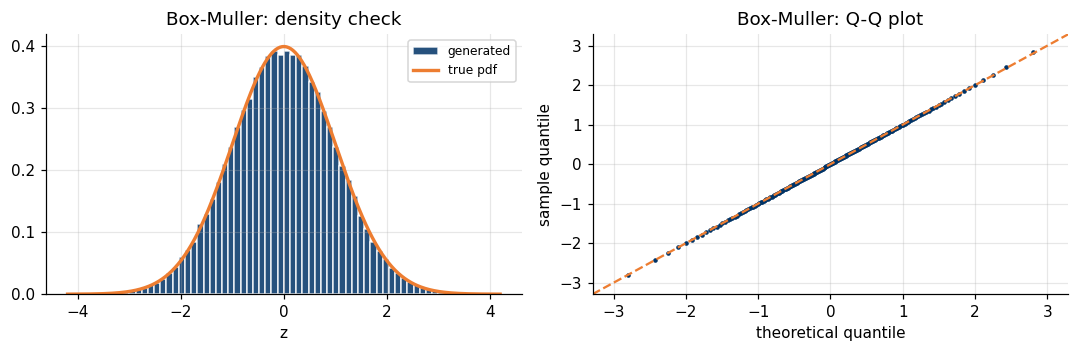


uniforms consumed per normal variate: 1.0000  (exactly 1, always)


In [ ]:
# ------------------------------------------------------------------
# 1.2  The basic Box-Muller sampler.
# ------------------------------------------------------------------

def box_muller(n, rng):
    """n standard normals via Box-Muller. Returns (samples, diagnostics)."""
    m = (n + 1) // 2                      # each uniform PAIR yields a normal PAIR
    u1 = 1.0 - rng.random(m)              # in (0,1]: protects log() from a zero
    u2 = rng.random(m)

    r = np.sqrt(-2.0 * np.log(u1))        # radius   R = sqrt(-2 ln U1)
    theta = 2.0 * np.pi * u2              # angle    Theta = 2 pi U2

    z = np.empty(2 * m)
    z[0::2] = r * np.cos(theta)           # Z1
    z[1::2] = r * np.sin(theta)           # Z2  -- the free second draw
    info = {"n_uniforms": 2 * m, "n_generated": 2 * m,
            "n_uniforms_needed": 2 * m, "n_attempts": m}
    return z[:n], info


z_bm, info_bm = box_muller(200_000, rng)
check_normal(z_bm, "Box-Muller")

print(f"\nuniforms consumed per normal variate: "
      f"{info_bm['n_uniforms'] / info_bm['n_generated']:.4f}  (exactly 1, always)")

### 1.3 General $N(\mu,\sigma^2)$, and the cost of the trig

A location–scale shift is all that is needed: $X = \mu + \sigma Z$.

The practical objection to Box–Muller is arithmetic: per **pair** of normals it evaluates
one $\ln$, one $\sqrt{\ \ }$, one $\cos$ and one $\sin$. Transcendental functions are
expensive relative to multiplication, which motivates the **Marsaglia polar method** — a
rejection-based variant that gets the sine and cosine *for free* from geometry.

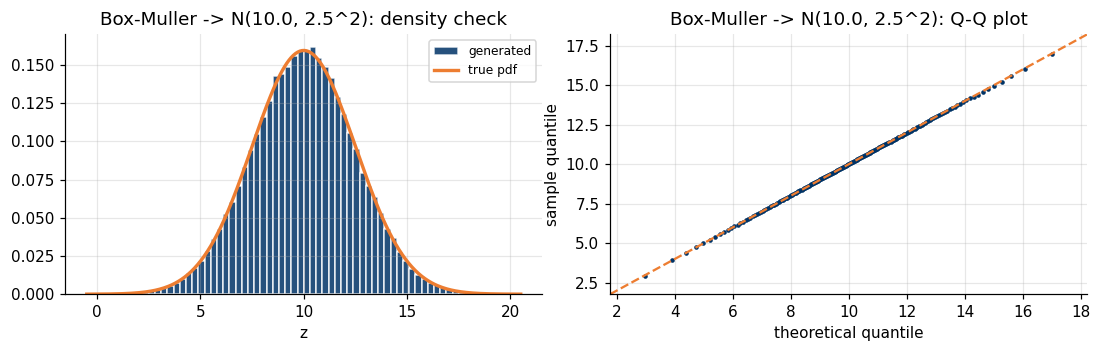

target mean 10.0, target sd 2.5


In [ ]:
# ------------------------------------------------------------------
# 1.5  N(mu, sigma^2) by location-scale shift.
# ------------------------------------------------------------------
mu, sigma = 10.0, 2.5
z, _ = box_muller(100_000, rng)
x = mu + sigma * z

check_normal(x, f"Box-Muller -> N({mu}, {sigma}^2)", mu=mu, sigma=sigma)
print(f"target mean {mu}, target sd {sigma}")

---
# Part 2 — The Ratio-of-Uniforms Method

### 2.1
**Theorem (Kinderman–Monahan, 1977).** Let $h(x) \ge 0$ be proportional to the target
density, $f = h / \int h$. Define the planar region

$$C = \Big\{ (u,v) \;:\; 0 < u \le \sqrt{h(v/u)} \Big\}.$$

If $(U,V)$ is uniform on $C$, then $X = V/U$ has density $f$.

### 2.2 Sampling uniformly on $C$

$C$ is usually an awkward shape, so we do the obvious thing: enclose it in a rectangle and
reject. For unimodal $h$ with bounded $x\sqrt{h(x)}$,

$$a = \sup_x \sqrt{h(x)}, \qquad b^+ = \sup_x x\sqrt{h(x)}, \qquad b^- = \inf_x x\sqrt{h(x)},$$

give $C \subseteq [0,a] \times [b^-,b^+]$.

**Algorithm.** Draw $U \sim U(0,a)$ and $V \sim U(b^-,b^+)$; set $X = V/U$; accept if
$U \le \sqrt{h(X)}$; otherwise repeat.

**Efficiency.** The acceptance probability is the area ratio

$$P(\text{accept}) = \frac{\mathrm{Area}(C)}{a\,(b^+-b^-)} = \frac{\tfrac12\int h}{a\,(b^+-b^-)} .$$

#### Worked example: the standard Normal

Take $h(x) = e^{-x^2/2}$. Then $\sqrt{h(x)} = e^{-x^2/4}$ and

$$a = \sup_x e^{-x^2/4} = 1 \ (\text{at } x=0), \qquad
\frac{d}{dx}\Big[x e^{-x^2/4}\Big] = e^{-x^2/4}\Big(1-\frac{x^2}{2}\Big) = 0
\Rightarrow x = \sqrt2,$$

$$b^+ = \sqrt2\,e^{-1/2} = \sqrt{2/e} \approx 0.85776, \qquad b^- = -b^+ .$$

The acceptance test $U \le \sqrt{h(X)} = e^{-X^2/4}$ rearranges to $X^2 \le -4\ln U$, so

$$P(\text{accept}) = \frac{\tfrac12\sqrt{2\pi}}{1 \cdot 2\sqrt{2/e}} \approx 0.7306 .$$

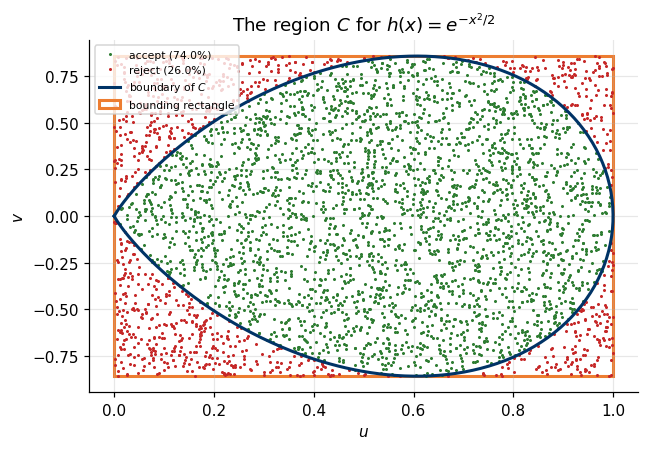

a  = 1.000000      b+ = -b- = 0.857764
Area(C) = (1/2)*int h = 1.253314,  rectangle area = 1.715528
theoretical acceptance = 0.7306    empirical here = 0.7400


In [ ]:
# ------------------------------------------------------------------
# 2.2  Draw the region C for the Normal, its bounding rectangle, and
#      the points that get accepted or rejected.
# ------------------------------------------------------------------
h_normal = lambda x: np.exp(-x**2 / 2)          # target kernel (unnormalised!)

A_N = 1.0                                        # a   = sup sqrt(h)
B_N = math.sqrt(2 / math.e)                      # b+  = sup x sqrt(h) = sqrt(2)*exp(-1/2)

# Boundary of C, parametrised by x: (u, v) = (sqrt(h(x)), x*sqrt(h(x))).
xb = np.linspace(-40, 40, 4000)
ub = np.sqrt(h_normal(xb))
vb = xb * ub

# A cloud of proposals in the bounding rectangle.
n_show = 4000
u = 1.0 - rng.random(n_show)                     # Uniform(0, a] with a = 1
v = B_N * (2 * rng.random(n_show) - 1.0)         # Uniform(b-, b+)
x_prop = v / u
acc = x_prop**2 <= -4 * np.log(u)                # <=> u <= exp(-x^2/4) = sqrt(h(x))

area_C = 0.5 * math.sqrt(2 * math.pi)            # (1/2) * integral of h
area_R = A_N * 2 * B_N

fig, ax = plt.subplots(figsize=(6, 4.2))

ax.plot(u[acc], v[acc], ".", ms=2, color=GREEN, label=f"accept ({acc.mean():.1%})")
ax.plot(u[~acc], v[~acc], ".", ms=2, color=RED, label=f"reject ({1-acc.mean():.1%})")
ax.plot(ub, vb, color=BLUE, lw=2, label="boundary of $C$")
ax.add_patch(plt.Rectangle((0, -B_N), A_N, 2 * B_N, fill=False,
                              edgecolor=ORANGE, lw=2, label="bounding rectangle"))
ax.set_xlabel("$u$"); ax.set_ylabel("$v$")
ax.set_title("The region $C$ for $h(x)=e^{-x^2/2}$")
ax.legend(fontsize=7, loc="upper left")


plt.tight_layout(); plt.show()

print(f"a  = {A_N:.6f}      b+ = -b- = {B_N:.6f}")
print(f"Area(C) = (1/2)*int h = {area_C:.6f},  rectangle area = {area_R:.6f}")
print(f"theoretical acceptance = {area_C/area_R:.4f}    empirical here = {acc.mean():.4f}")

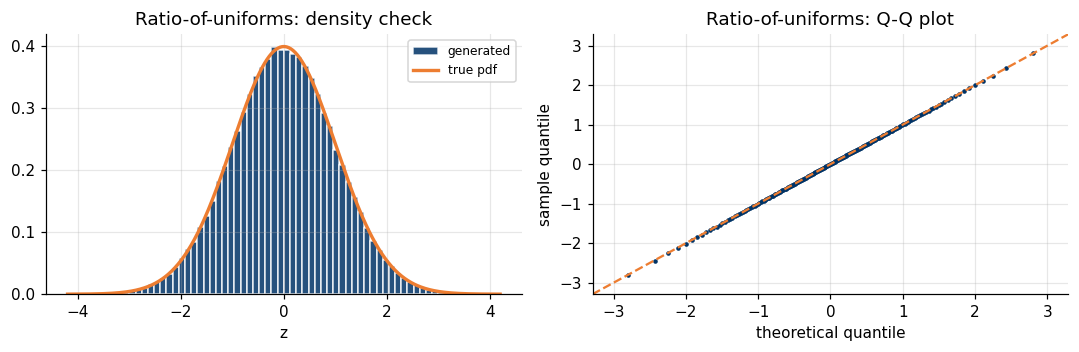


empirical acceptance rate   = 0.7303  (theory 0.7306)
uniforms per normal variate = 2.7387  (theory 2.7376)

No trigonometry and no square root -- one logarithm and one division.


In [ ]:
# ------------------------------------------------------------------
# 2.3  The ratio-of-uniforms sampler for the standard Normal.
# ------------------------------------------------------------------

def ratio_of_uniforms_normal(n, rng):
    """n standard normals by the Kinderman-Monahan ratio-of-uniforms method."""
    B = math.sqrt(2 / math.e)                  # b+ ; a = 1 so U ~ Uniform(0,1]
    p_acc = 0.5 * math.sqrt(2 * math.pi) / (2 * B)
    out, masks, used, made = [], [], 0, 0

    while made < n:
        m = max(1_000, int(np.ceil((n - made) / p_acc * 1.15)))
        u = 1.0 - rng.random(m)                # Uniform(0,1] -- never zero
        v = B * (2.0 * rng.random(m) - 1.0)    # Uniform(b-, b+)
        used += 2 * m

        x = v / u
        acc = x * x <= -4.0 * np.log(u)        # U <= sqrt(h(X)) rearranged
        out.append(x[acc]); masks.append(acc); made += int(acc.sum())

    # proposals actually needed for the first n variates (see Part 3)
    attempts_needed = int(np.flatnonzero(np.concatenate(masks))[:n][-1]) + 1

    z = np.concatenate(out)
    info = {"n_uniforms": used, "n_generated": made,
            "n_uniforms_needed": 2 * attempts_needed,
            "acceptance": made / (used / 2)}
    return z[:n], info


z_rou, info_rou = ratio_of_uniforms_normal(200_000, rng)
check_normal(z_rou, "Ratio-of-uniforms")

print(f"\nempirical acceptance rate   = {info_rou['acceptance']:.4f}  (theory 0.7306)")
print(f"uniforms per normal variate = "
      f"{info_rou['n_uniforms']/info_rou['n_generated']:.4f}  (theory {2/0.73056:.4f})")
print("\nNo trigonometry and no square root -- one logarithm and one division.")

---
# Part 3 — Box–Muller vs Ratio-of-Uniforms

Both methods are *exactly* correct. The question
is which to reach for?

| # | Metric | Why |
|:--|:--|:--|
| 1 | Uniforms consumed per variate | the real bottleneck |
| 2 | Wall-clock runtime | waiting time |

We include the NumPy's compiled **Ziggurat**
generator as reference points.

In [ ]:
# ------------------------------------------------------------------
# 3.1  A common interface. Every sampler: (n, rng) -> (samples, info).
# ------------------------------------------------------------------
def numpy_ziggurat(n, rng):
    """NumPy's own generator: a compiled Ziggurat implementation, our benchmark."""
    return rng.standard_normal(n), {"n_uniforms": np.nan, "n_generated": n,
                                    "n_uniforms_needed": np.nan}

SAMPLERS = {
    "Box-Muller":          box_muller,
    "Ratio-of-uniforms":   ratio_of_uniforms_normal,
    "NumPy (Ziggurat)":    numpy_ziggurat,
}

### 3.1 Metric 1 — Uniforms consumed per variate


| Method | Uniforms per normal | Why |
|:--|:--|:--|
| Box–Muller | $1$ exactly | 2 uniforms $\to$ 2 normals, never rejects |
| Ratio-of-uniforms | $2/0.7306 \approx 2.738$ | 2 uniforms $\to$ **1** normal, accepted w.p. $0.7306$ |

Box–Muller is close to information-theoretically frugal; ratio-of-uniforms burns nearly
three times as many uniforms for the same output.

,uniforms / variate (measured),uniforms / variate (theory),acceptance rate
method,,,
Box-Muller,1.0000,1.0000,1.0000
Ratio-of-uniforms,2.7367,2.7376,0.7306


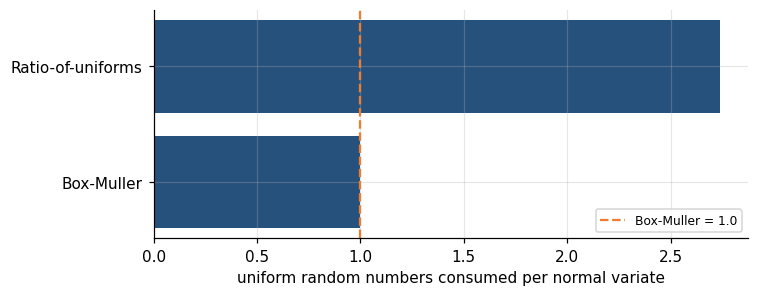

In [ ]:
# ------------------------------------------------------------------
# 3.1  Uniforms consumed: theory vs measurement.
#      `n_uniforms_needed` counts draws up to the n-th accepted variate,
#      so the over-draw of the final batch does not distort the ratio.
# ------------------------------------------------------------------
n_eff = 500_000
theory = {"Box-Muller": 1.0, "Polar (Marsaglia)": 4 / np.pi,
          "Ratio-of-uniforms": 2 / 0.73056, "RoU (division-free)": 2 / 0.73056}

rows = []
for name, fn in SAMPLERS.items():
    if name.startswith("NumPy"):
        continue
    _, info = fn(n_eff, rng)
    rows.append({
        "method": name,
        "uniforms / variate (measured)": round(info["n_uniforms_needed"] / n_eff, 4),
        "uniforms / variate (theory)": round(theory[name], 4),
        "acceptance rate": round(info.get("acceptance", 1.0), 4),
    })
eff = pd.DataFrame(rows).set_index("method")
display(eff)

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(eff.index, eff["uniforms / variate (measured)"], color=BLUE, alpha=0.85)
ax.axvline(1.0, color=ORANGE, ls="--", lw=1.5, label="Box-Muller = 1.0")
ax.set_xlabel("uniform random numbers consumed per normal variate")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3.2 Metric 2 — Runtime

Two honest caveats before reading the numbers.

1. NumPy's generator is compiled C; ours are Python-level (though fully vectorised), so the
   fair comparison is *among our three*, with NumPy as a floor.

,"n = 10,000 (ns/variate)","n = 100,000 (ns/variate)","n = 1,000,000 (ns/variate)"
Box-Muller,33.10,32.80,20.56
Ratio-of-uniforms,21.30,19.15,42.78
NumPy (Ziggurat),7.95,7.88,8.01


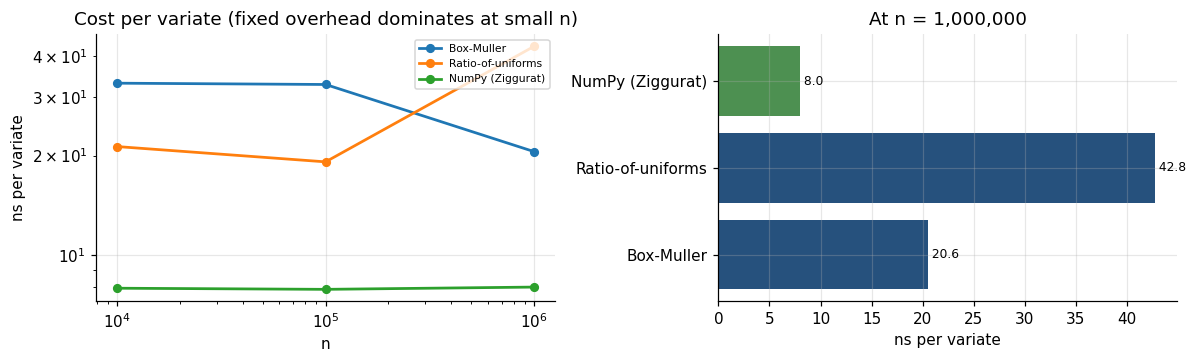

Relative to Box-Muller at the largest size:
  Box-Muller              1.00x
  Ratio-of-uniforms       2.08x
  NumPy (Ziggurat)        0.39x


In [ ]:
# ------------------------------------------------------------------
# 3.2  Vectorised runtime: nanoseconds per variate, over three sizes.
# ------------------------------------------------------------------
def bench(fn, n, repeat=5):
    """Best-of-`repeat` wall time, reported as nanoseconds per generated variate."""
    ts = timeit.repeat(lambda: fn(n, rng), repeat=repeat, number=1)
    return min(ts) / n * 1e9

sizes = [10_000, 100_000, 1_000_000]
timings = {name: [bench(fn, n) for n in sizes] for name, fn in SAMPLERS.items()}

tbl = pd.DataFrame(timings, index=[f"n = {s:,}" for s in sizes]).T
display(tbl.round(2).rename(columns=lambda c: c + "  (ns/variate)"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for name, ts in timings.items():
    ax[0].plot(sizes, ts, "o-", lw=1.8, ms=5, label=name)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("n"); ax[0].set_ylabel("ns per variate")
ax[0].set_title("Cost per variate (fixed overhead dominates at small n)")
ax[0].legend(fontsize=7)

big = [timings[k][-1] for k in SAMPLERS]
ax[1].barh(list(SAMPLERS), big, color=[BLUE, BLUE, GREEN, GREEN, ORANGE], alpha=0.85)
ax[1].set_xlabel("ns per variate"); ax[1].set_title(f"At n = {sizes[-1]:,}")
for i, v in enumerate(big):
    ax[1].text(v, i, f" {v:.1f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

base = timings["Box-Muller"][-1]
print("Relative to Box-Muller at the largest size:")
for k in SAMPLERS:
    print(f"  {k:22s} {timings[k][-1]/base:5.2f}x")


### Wrap-up

Box–Muller is very elegant: it converts the Normal's defining rotational
symmetry directly into an algorithm, wastes no uniforms, and never loops.
Ratio-of-uniforms is the more useful *framework*: it costs about 2.7 uniforms per variate
and rejects a quarter of its proposals, but it asks almost nothing of the target - no
inverse CDF, no normalising constant, only a bounding rectangle. That is the trade Module 5
will delve in, when the target is a posterior nobody can normalise.

### References

* Box, G. E. P. & Muller, M. E. (1958). A note on the generation of random normal deviates. *Annals of Mathematical Statistics* **29**(2), 610–611.
* Marsaglia, G. & Bray, T. A. (1964). A convenient method for generating normal variables. *SIAM Review* **6**(3), 260–264.
* Neave, H. R. (1973). On using the Box–Muller transformation with multiplicative congruential pseudo-random number generators. *Applied Statistics* **22**(1), 92–97.
* Kinderman, A. J. & Monahan, J. F. (1977). Computer generation of random variables using the ratio of uniform deviates. *ACM TOMS* **3**(3), 257–260.
* Leva, J. L. (1992). A fast normal random number generator. *ACM TOMS* **18**(4), 449–453.
* Devroye, L. (1986). *Non-Uniform Random Variate Generation*, Springer — Chapter VII.